# CS-GY 6313 / CUSP-GX 6006: Data Visualization - Spring '25
# Homework #3: Temporal Visualization

In this homework, you will be working with visualizations of stock data. To achieve this, we'll be using [``pandas``](https://pandas.pydata.org/docs/user_guide/10min.html) to get the specific information we want (e.g. closing price) from four datasets we've aggregated in the `datasets/` directory. We'll provide example code on how to load in the required data, but your task is to complete the code.

## Imports

**Don't modify this code**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

## Importing from dataset file

Below is a helper function that imports raw data from the url provided, performs some pre-processing to change the date format into DateTime, and returns the final dataframe. Feel free to use this helper function in your code implementation.

Below is an example of using the helper function to import the stock data from `./datasets/amzn.csv`:

In [2]:
def import_df(filename):
    df = pd.read_csv(filename)
    df['dates'] = pd.to_datetime(df['dates'], format='%Y-%m-%d')
    return df

example_df = import_df("./datasets/amzn.csv")

Now that you have the dates and closing prices of AMZN in a dataframe, you can plot! Remember that you can access and plot a specific column of a dataframe with the following code logic:

```
x = df['x_axis']
y = df['y_axis']
plt.plot(x, y)
```

Below is an example using Amazon's raw stock data.

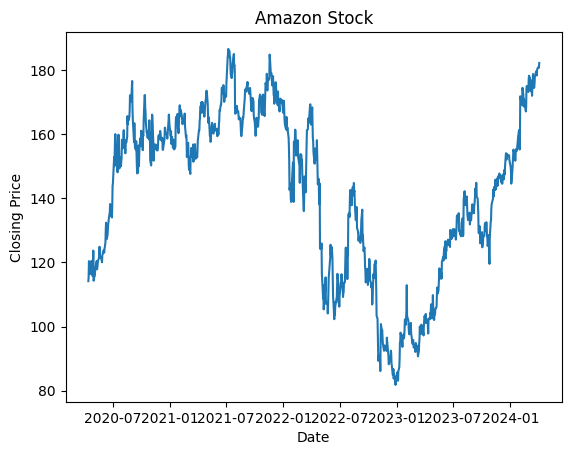

In [3]:
# Plot the dates vs. closing price for AMZN
fig = plt.figure()
plt.plot(example_df['dates'], example_df['closing price'])

plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title("Amazon Stock")
plt.show()

In [28]:
example_df.head()

,dates,closing price,volume
0,2020-04-14,114.166000,161744000
1,2020-04-15,115.384003,137332000
2,2020-04-16,120.409500,240764000
3,2020-04-17,118.750000,158600000
4,2020-04-20,119.680496,115414000


In [36]:
example_df.head()

,dates,closing price,volume
0,2020-04-14,114.166000,161744000
1,2020-04-15,115.384003,137332000
2,2020-04-16,120.409500,240764000
3,2020-04-17,118.750000,158600000
4,2020-04-20,119.680496,115414000


## Part 1: Curve-Based Visualization (5/15 points)

Temporally visualize the closing prices for the 1000 trading days of the 4 stocks as well as the mean (average) closing price across all 4 stocks for each day. Make sure to visualize all data in a single diagram. Color-code the plot so that each stock has a different color. Add a legend to let us know which plot represents which stock/data. An example is provided below:

In [29]:
# Part 1: Closing price of at least 4 stocks + the mean (or average) of those four stocks for the past 1000 trading days

"""
    To visualise closing prices for 4 stocks and their mean, we will make a dataframe combining all 4 stocks closing prices, their
    volumes and their dates, then add a column for their mean by averaging the other 4 stock columns, and then plotting it using
    matplotlib
"""

amzn = import_df("./datasets/amzn.csv")
aapl = import_df("./datasets/aapl.csv")
goog = import_df("./datasets/goog.csv")
meta = import_df("./datasets/meta.csv")
df = pd.DataFrame({
    "amzn": amzn["closing price"],
    "amzn_vol": amzn["volume"],
    "aapl": aapl["closing price"],
    "aapl_vol": aapl["volume"],
    "goog": goog["closing price"],
    "goog_vol": goog["volume"],
    "meta": meta["closing price"],
    "meta_vol": meta["volume"],
    "date": amzn["dates"]
})
df['mean'] = (df["amzn"]+df["aapl"]+df["goog"]+df['meta'])/4
df.head()

,amzn,amzn_vol,aapl,aapl_vol,goog,goog_vol,meta,meta_vol,date,mean
0,114.166000,161744000,69.989937,194994800,63.461498,49408000,177.981155,21011800,2020-04-14,106.399648
1,115.384003,137332000,69.351120,131154400,63.123501,33434000,176.782425,17423000,2020-04-15,106.160262
2,120.409500,240764000,69.902161,157125200,63.173500,50362000,176.063202,23593200,2020-04-16,107.387091
3,118.750000,158600000,68.953682,215250000,64.162498,38980000,179.050034,20974800,2020-04-17,107.729053
4,119.680496,115414000,67.522430,130015200,63.330502,33910000,178.051086,16110700,2020-04-20,107.146129


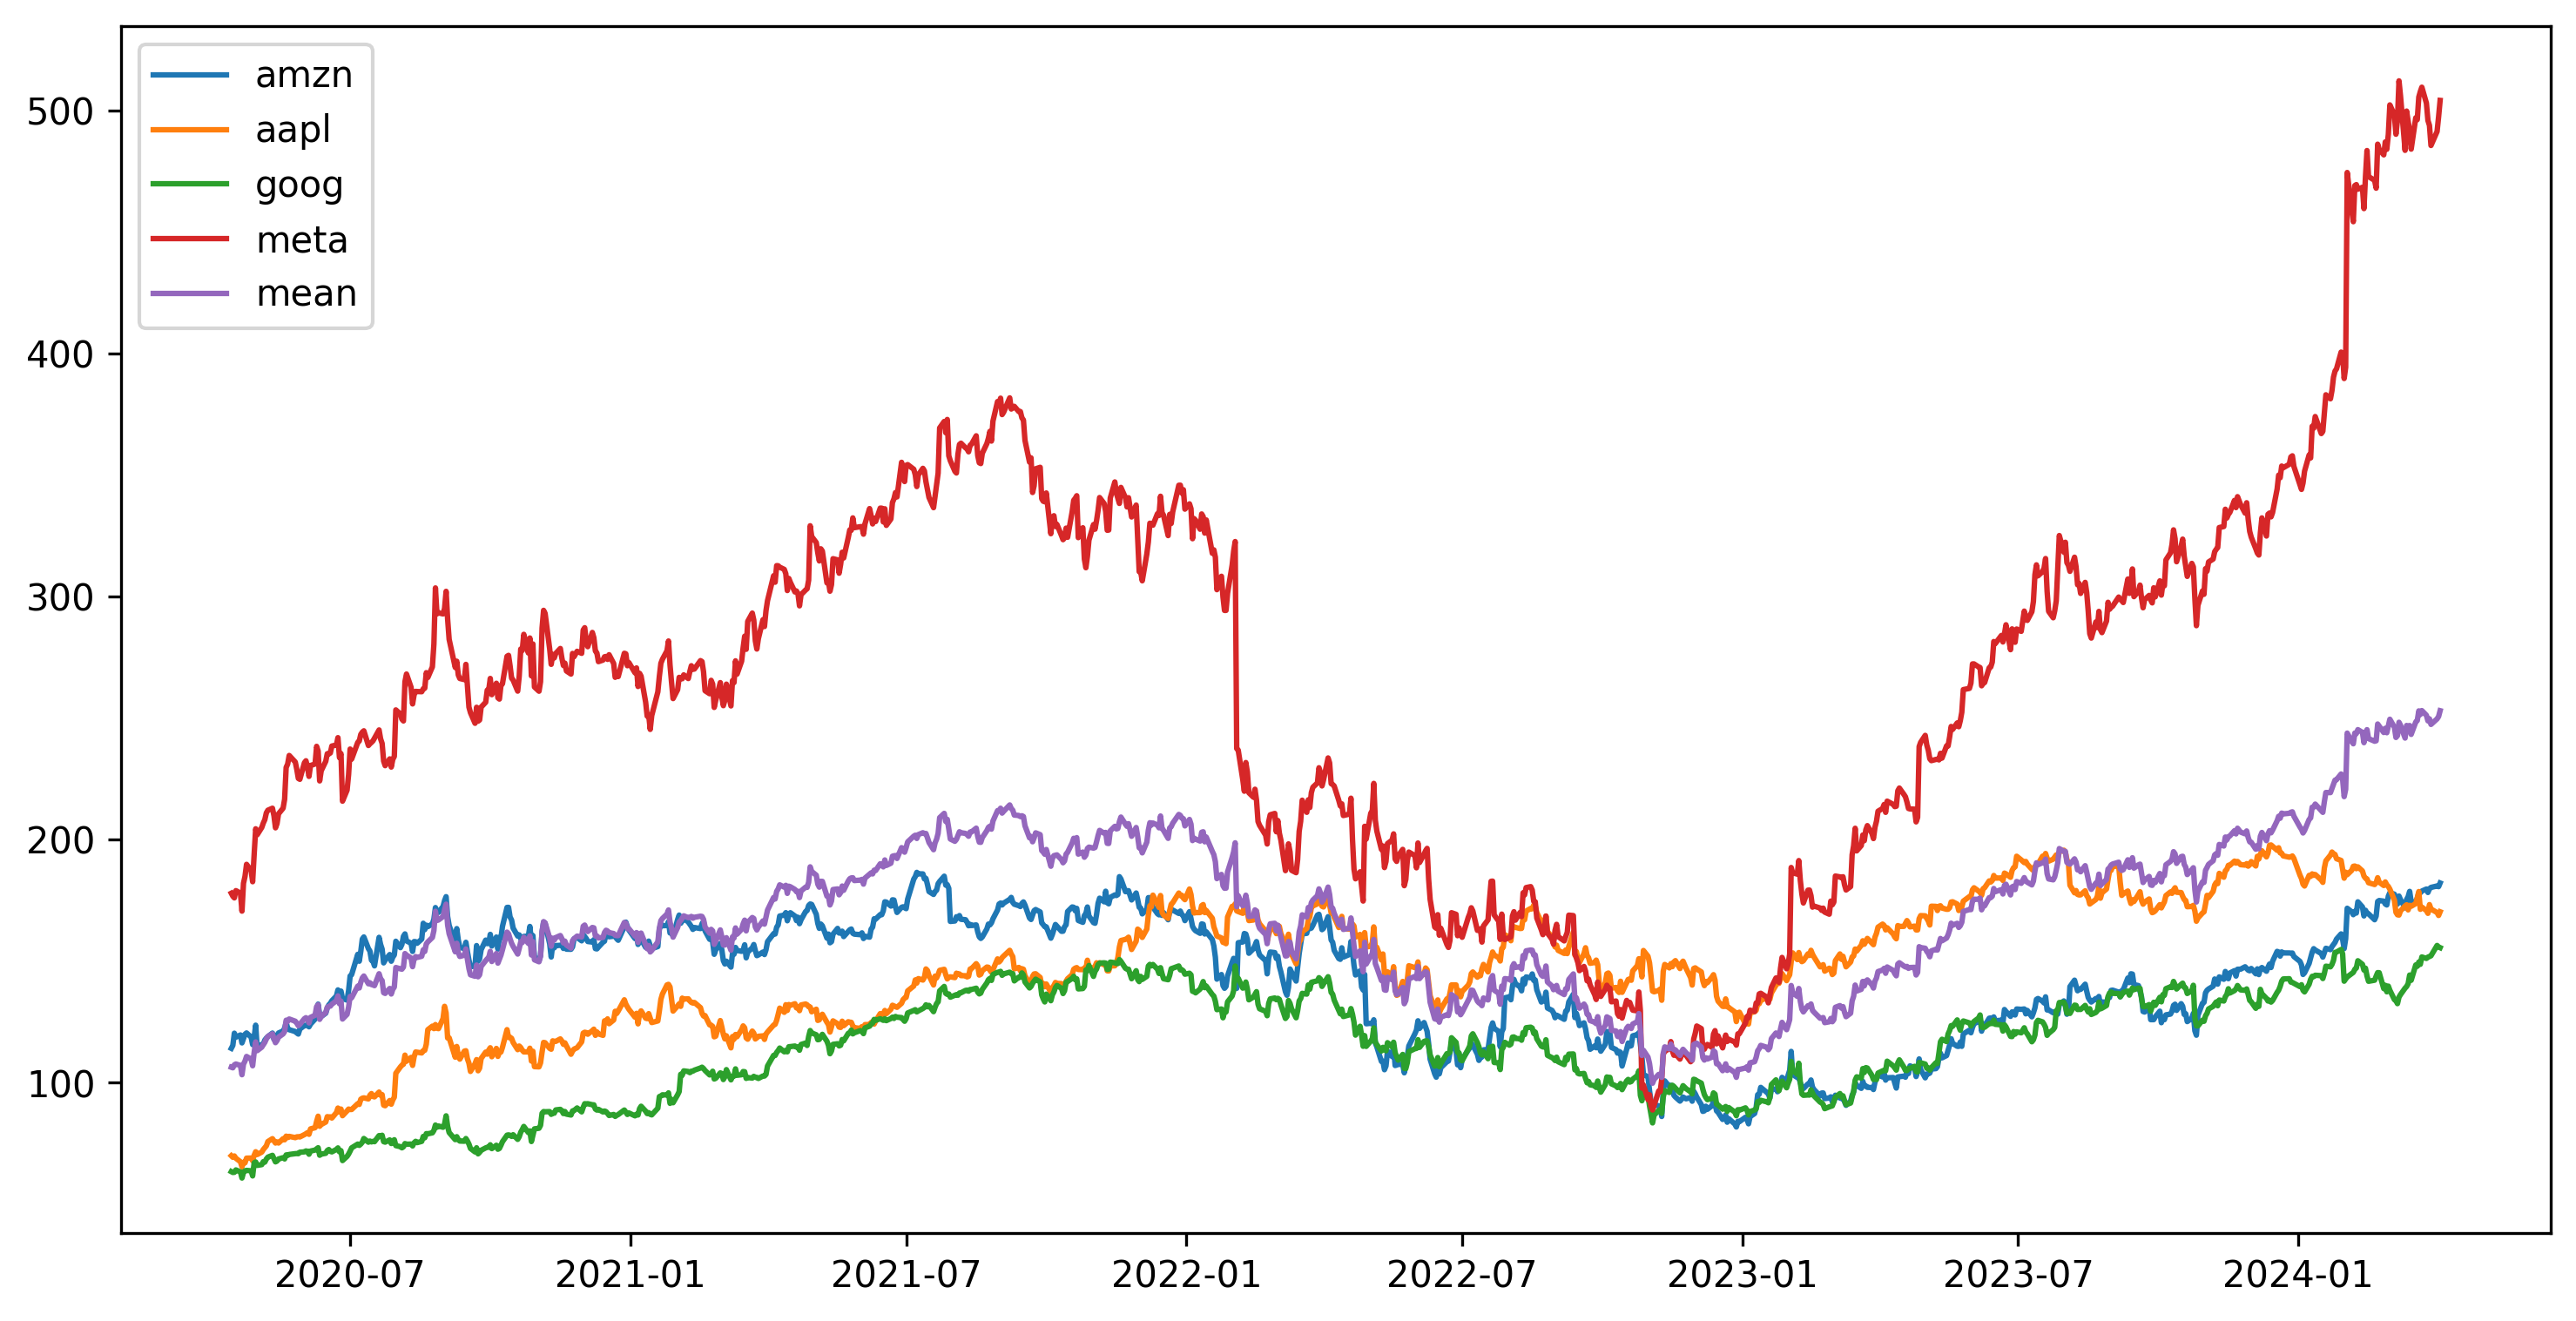

In [30]:
fig,ax = plt.subplots(figsize=(12,6),dpi=300)

ax.plot(df["date"],df["amzn"],label="amzn",)
ax.plot(df["date"],df["aapl"],label="aapl",)
ax.plot(df["date"],df["goog"],label="goog",)
ax.plot(df["date"],df["meta"],label="meta",)
ax.plot(df["date"],df["mean"],label="mean",)

ax.legend()

## Part 2: Stacked Area Visualization (8/15 points)

Your task here is to plot two different plots. The first plot is the _stacked area chart_ of the _volumes_ of the 4 stocks. The second plot is the same, except you need to plot the _**percentage** stacked area chart_. To achieve the latter, you will need to find the percentages of the total volume for each of your stocks on each day.

Make sure to color-code your area plots so that it's easy to distinguish the stocks, and add a legend to help us identify which data represents which stock. There is no need to visualize the mean data here.

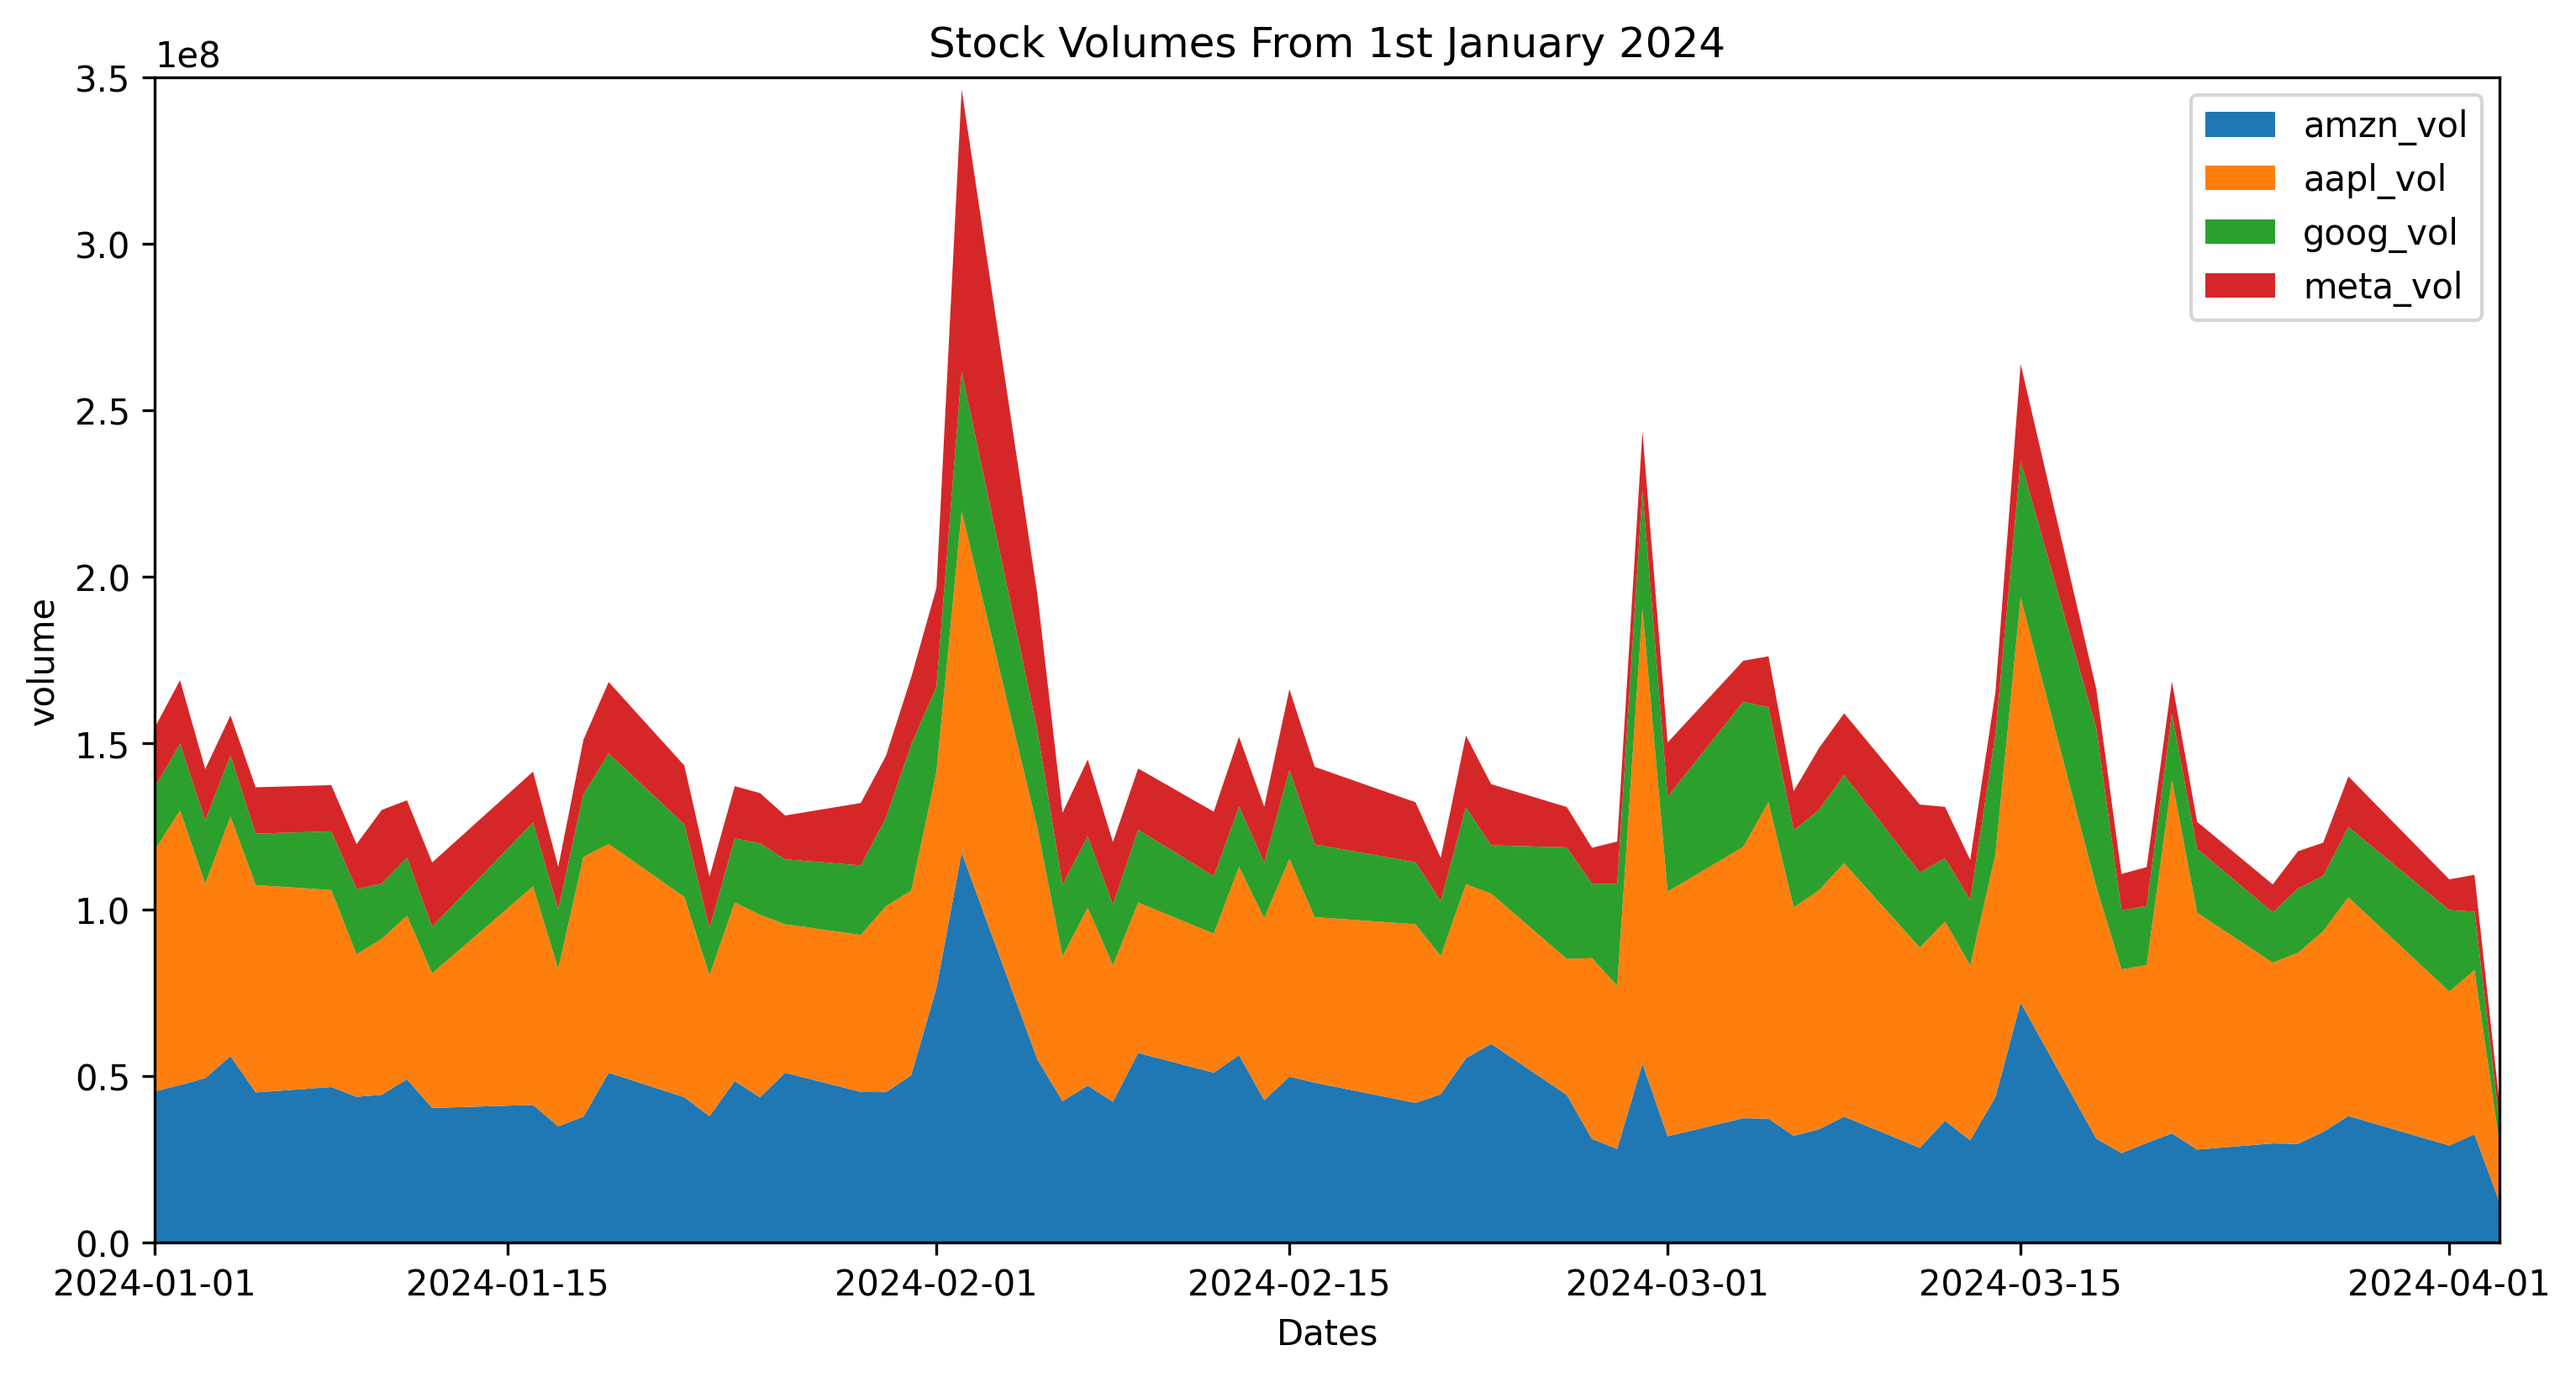

In [76]:
# Part 2: Both normal and percentage stacked area charts of the volume of the stocks for the past 1000 trading days

"""
    Using Stackplot to create a stacked are chart, adding xlim on data from 1st Jan 2024 for better readability, and adding a limit to the y axis of 3.5*10e8
"""

fig,axs = plt.subplots(figsize=(12,6),dpi=300)
axs.stackplot(df['date'],df['amzn_vol'],df['aapl_vol'],df['goog_vol'],df['meta_vol'],labels=['amzn_vol','aapl_vol','goog_vol','meta_vol'])

plt.xlim(pd.Timestamp("2024-01-01"),pd.Timestamp("2024-04-03"))
plt.ylim(0,3.5*1e8)
plt.title("Stock Volumes From 1st January 2024")
plt.xlabel("Dates")
plt.ylabel("volume")
axs.legend()

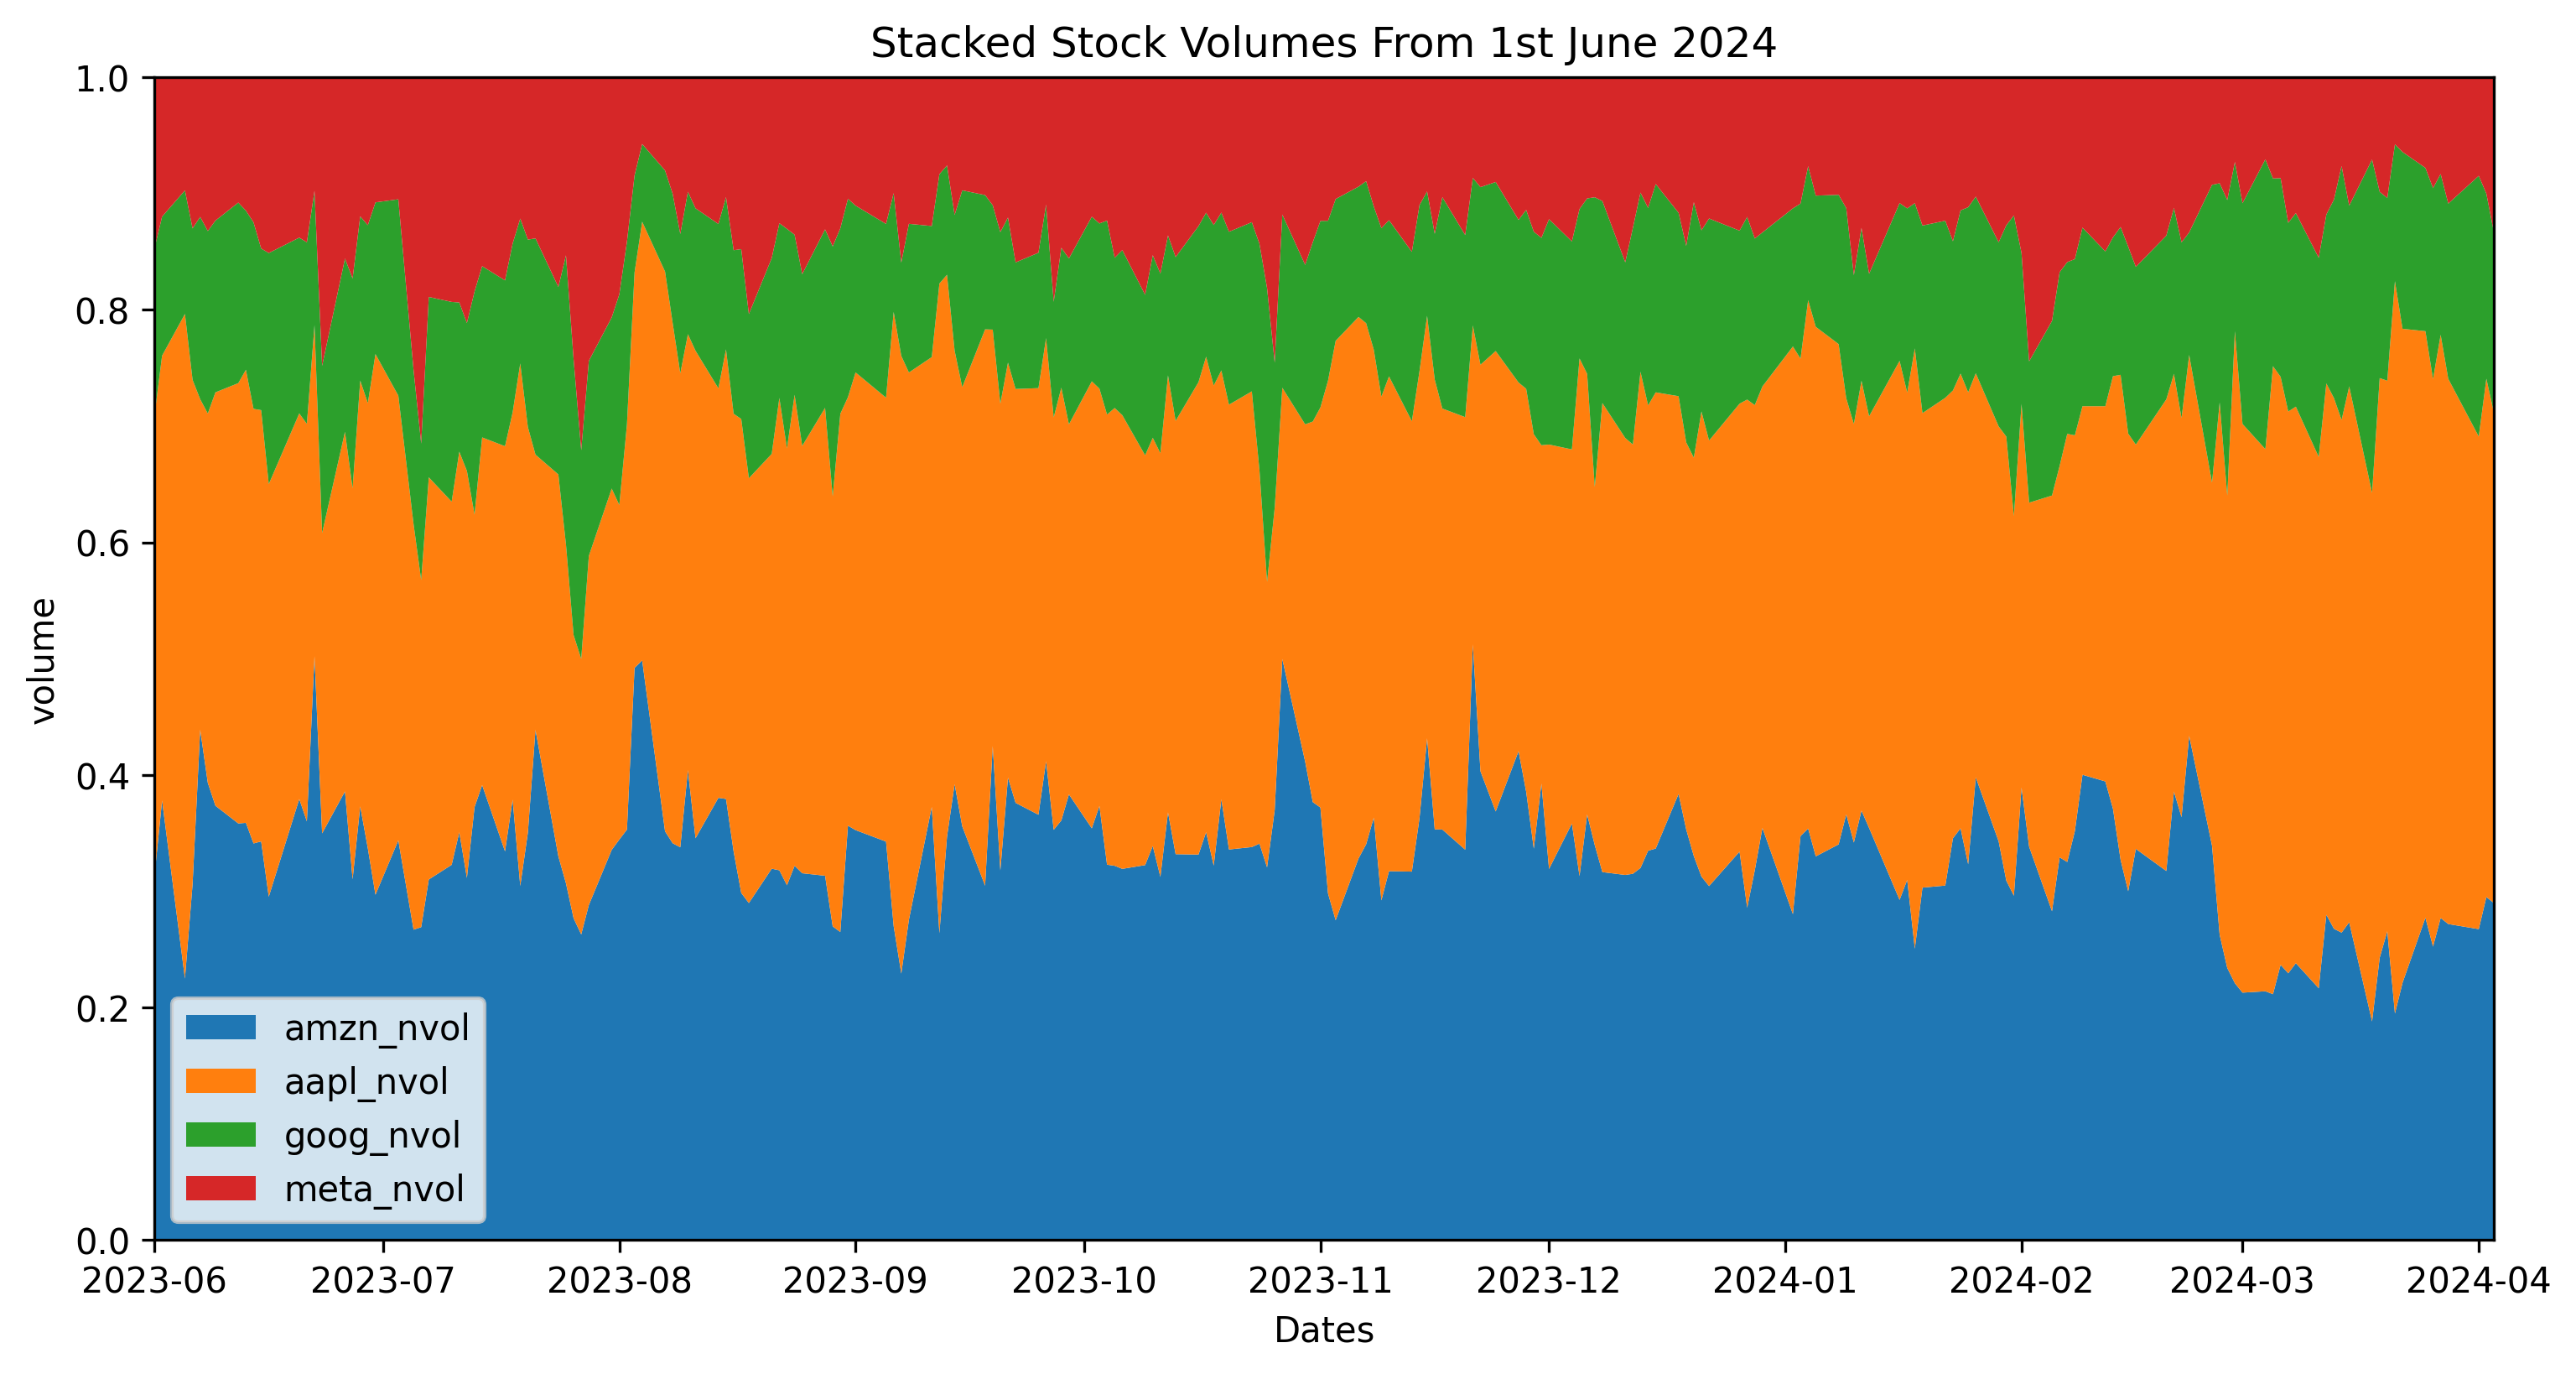

In [77]:
"""
    Matplotlib does not have a percentage stacked plot, so we need to add up the stocks and normalise across each day. 
"""
volume = np.vstack([df["amzn_vol"],df["aapl_vol"],df["goog_vol"],df["meta_vol"]])
norm = volume.sum(axis=0)
nvol = volume/norm
df['amzn_nvol'] = nvol[0]
df['aapl_nvol'] = nvol[1]
df['goog_nvol'] = nvol[2]
df['meta_nvol'] = nvol[3]

fig,axs = plt.subplots(figsize=(12,6),dpi=300)
axs.stackplot(df['date'],df['amzn_nvol'],df['aapl_nvol'],df['goog_nvol'],df['meta_nvol'],labels=['amzn_nvol','aapl_nvol','goog_nvol','meta_nvol'])

plt.xlim(pd.Timestamp("2023-06-01"),pd.Timestamp("2024-04-03"))
plt.ylim(0,1)
plt.title("Stacked Stock Volumes From 1st June 2024")
plt.xlabel("Dates")
plt.ylabel("volume")
axs.legend()

## Part 3: Meaning behind the Data? (2/15 points)

Within 2-5 sentences for each, answer the following:

1. Do you notice any trends in the closing prices of each company's stock? What might these patterns indicate regarding the performance of these tech companies? (1 point)

2. Who occupies the biggest volume percentage across the four companies? What does this tell you about the performance of these tech companies? (1 point)

Feel free to write down your analyses inside this notebook or as a standalone document.

1. The stock prices of most companies spike or dip around quarterly reports (March-end, June-end, September-end, and December-end). This corresponds to companies releasing their quarterly earning reports, which can either be good earnings (boosting investor confidence, who buy more stock) or bad earnings (losing confidence, investors selling stock). All companies had a steady incline during the lockdown caused by the pandemic (2020-2022) as company costs plummeted due to remote work being mandatory. No employees coming into ofcourse meant that less money spent on electricity, food, and other amenities, which meant more money in earnings. Meta had a catastrophic dip in 2022, which was due to the [failure of the metaverse](https://www.fool.com/investing/2023/01/11/why-the-metaverse-and-meta-flopped-in-2022/). Other than that, most companies have had a steady incline, with boosts 2023 onwards due to the AI Boom

2. The biggest volume precentage across the four companies is Apple (AAPL), with Amazon (AMZN) as a close second, this implies that Apple and Amazon have more stock volume, meaning more investors. Google (GOOG) and Meta (META) have smaller volumes compared to the other two, but have similar growth patterns regradless